In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def generate_data(num_samples):
    np.random.seed(42)
    X = np.random.rand(num_samples, 1)* 10
    y = 3 * X + 7 + np.random.randn(num_samples, 1 )
    return X, y

In [5]:
X, y = generate_data(50)

In [163]:
def compute_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [164]:
n_epochs = 100
lr = 0.003

In [165]:
# parameter initialization
batch_theta_ = np.random.randn(X.shape[1] + 1, 1) # + 1 is for bias
sgd_theta_ = np.random.randn(X.shape[1] + 1, 1) # + 1 is for bias

In [166]:
class Batch_GD:
    def __init__(self, parameters, epochs=100, lr=0.01, print_on_step=None):

        self.lr = lr
        self.n_epochs = epochs
        self.print_on_step = print_on_step
        
        self.theta_ = parameters

        self.loss_history = []

    def optimize(self, X, y):
        n_points, n_features = X.shape     
        X = np.c_[np.ones((n_points, 1)), X]

        for epoch in range(self.n_epochs):
            # calculating predictions
            
            y_pred = np.dot(X, self.theta_)
            errors = y - y_pred
            gradients = - 2/n_points * X.T.dot(errors)
            self.theta_ -= self.lr * gradients

            loss = compute_loss(y, y_pred)
            if self.print_on_step:
                if (epoch+1)%self.print_on_step == 0:
                    print(f"Epoch: {epoch}, Loss: {loss:.4f}")
            self.loss_history.append(loss)



In [167]:
class SGD:
    def __init__(self, parameters, epochs=100, lr=0.01, print_on_step=None):
        self.n_epochs = epochs
        self.lr = lr
        self.theta_ = parameters

        self.print_on_step = print_on_step
        self.loss_history = []

    def optimize(self, X, y):
        n_points, n_features = X.shape
        X = np.c_[np.ones((n_points,1)),X]
        for epoch in range(self.n_epochs): 
            data_idx = np.random.randint(n_points)
            xi = X[data_idx:data_idx+1] # this will give us 2d data
            yi = y[data_idx:data_idx+1]

            y_pred = xi.dot(self.theta_)
            error = yi - y_pred
            loss = compute_loss(yi, y_pred)

            gradient = -2 * np.dot(xi.T,error)
            self.theta_ -= self.lr * gradient

            if self.print_on_step:
                if(epoch+1)%self.print_on_step==0:
                    print(f"Epoch: {epoch}, Loss: {loss:.4f}")
            self.loss_history.append(loss)


In [168]:
batch_gd = Batch_GD(batch_theta_, n_epochs, lr, print_on_step = 10)

In [169]:
sgd = SGD(sgd_theta_, n_epochs, lr, print_on_step=10)

In [170]:
sgd.optimize(X,y)

Epoch: 9, Loss: 27.4584
Epoch: 19, Loss: 0.0059
Epoch: 29, Loss: 0.1899
Epoch: 39, Loss: 25.2754
Epoch: 49, Loss: 1.1335
Epoch: 59, Loss: 13.8002
Epoch: 69, Loss: 17.2875
Epoch: 79, Loss: 38.0834
Epoch: 89, Loss: 30.5140
Epoch: 99, Loss: 36.5933


In [171]:
batch_gd.optimize(X,y)

Epoch: 9, Loss: 21.8796
Epoch: 19, Loss: 12.6040
Epoch: 29, Loss: 12.0153
Epoch: 39, Loss: 11.6354
Epoch: 49, Loss: 11.2725
Epoch: 59, Loss: 10.9218
Epoch: 69, Loss: 10.5830
Epoch: 79, Loss: 10.2555
Epoch: 89, Loss: 9.9390
Epoch: 99, Loss: 9.6331


Final Parameters using Batch GD: m = 3.8586, c = 1.6085
Final Parameters using SGD: m = 3.8846, c = 1.1221


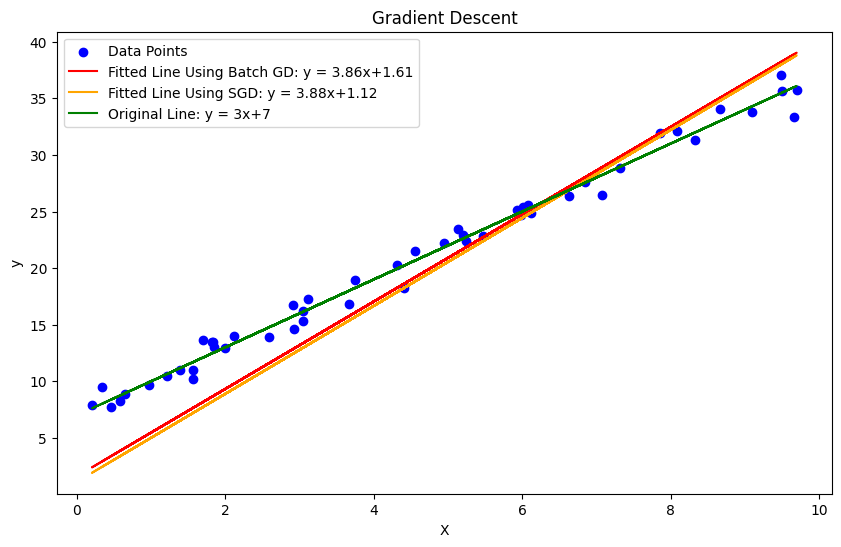

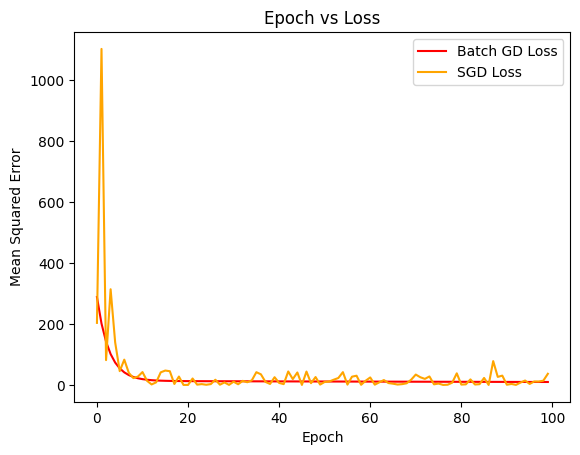

In [ ]:
c,m = batch_gd.theta_
c1,m1 = sgd.theta_
print(f"Final Parameters using Batch GD: m = {m[0]:.4f}, c = {c[0]:.4f}")
print(f"Final Parameters using SGD: m = {m1[0]:.4f}, c = {c1[0]:.4f}")
plt.figure(figsize=(10,6))
plt.scatter(X,y,label='Data Points',color='blue')
plt.plot(X,np.c_[np.ones((X.shape[0],1)),X].dot(batch_gd.theta_),label=f"Fitted Line Using Batch GD: y = {m[0]:.2f}x+{c[0]:.2f}",color='red')
plt.plot(X,np.c_[np.ones((X.shape[0],1)),X].dot(sgd.theta_),label=f"Fitted Line Using SGD: y = {m1[0]:.2f}x+{c1[0]:.2f}",color='orange')
plt.plot(X,3*X+7,label=f"Original Line: y = {3}x+{7}",color='green')
plt.title("Gradient Descent")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

plt.plot(batch_gd.loss_history,label="Batch GD Loss",color='red')
plt.plot(sgd.loss_history,label="SGD Loss",color='orange')
plt.title("Epoch vs Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.show()

In [72]:
def generate_data(num_samples):
    np.random.seed(40)
    X = np.random.rand(num_samples,1) * 10
    y = 3 * X + 7 + np.random.randn(num_samples,1)
    return X,y

In [73]:
X, y = generate_data(50)

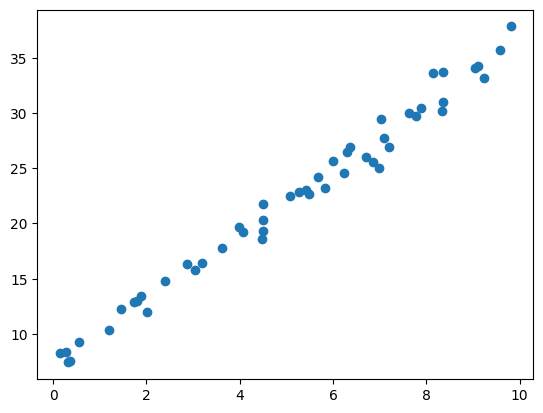

In [74]:
plt.scatter(X,y)

In [75]:
def compute_loss(y_pred,y_true):
    return np.mean((y_pred - y_true)**2)

In [76]:
theta_ = np.random.randn(X.shape[1]+1,1)
theta_.shape, theta_

((2, 1),
 array([[-1.69268465],
        [-0.61963465]]))

In [77]:
class GD():
    def __init__(self, parameters, epochs=100, lr=0.1, beta=0.9, print_on_step=None):
        self.n_epochs = epochs
        self.lr = lr
        self.theta_ = parameters
        self.pairs = [self.theta_.copy().reshape(-1)]
        self.print_on_step = print_on_step
        self.v = self.theta_
        self.beta = beta
        self.loss_history = []
    def optimize(self,X,y):
        n_points, _ = X.shape 
        X = np.c_[np.ones((n_points,1)),X]
        for epoch in range(self.n_epochs):
            data_idx = np.random.randint(n_points)
            Xi = X[data_idx:data_idx+1]
            yi = y[data_idx:data_idx+1]

            y_pred = np.dot(Xi, self.theta_)
            error = y_pred - yi 

            loss = compute_loss(y_pred,yi)

            gradient = 2 * np.dot(Xi.T, error)

            self.theta_ -= self.lr * gradient
            self.pairs.append(self.theta_.copy().reshape(-1))
            if self.print_on_step:
                if (epoch)%self.print_on_step==0:
                    print(f'Epoch: {epoch}, Loss: {loss:.4f}')

            self.loss_history.append(loss)


In [78]:
epochs = 1000
lr = 0.01

In [79]:
gd = GD(theta_,epochs=epochs, lr=lr, print_on_step=10)

In [80]:
gd.optimize(X,y)

Epoch: 0, Loss: 1436.4756
Epoch: 10, Loss: 39.4831
Epoch: 20, Loss: 0.5427
Epoch: 30, Loss: 60.6245
Epoch: 40, Loss: 8.2040
Epoch: 50, Loss: 28.7170
Epoch: 60, Loss: 16.3424
Epoch: 70, Loss: 15.3120
Epoch: 80, Loss: 0.0032
Epoch: 90, Loss: 0.6763
Epoch: 100, Loss: 12.3791
Epoch: 110, Loss: 14.4731
Epoch: 120, Loss: 7.1992
Epoch: 130, Loss: 10.5410
Epoch: 140, Loss: 2.6186
Epoch: 150, Loss: 0.7310
Epoch: 160, Loss: 8.3725
Epoch: 170, Loss: 10.3215
Epoch: 180, Loss: 0.0121
Epoch: 190, Loss: 5.9983
Epoch: 200, Loss: 0.2324
Epoch: 210, Loss: 4.5153
Epoch: 220, Loss: 0.0080
Epoch: 230, Loss: 0.2099
Epoch: 240, Loss: 0.2089
Epoch: 250, Loss: 9.5586
Epoch: 260, Loss: 6.1790
Epoch: 270, Loss: 0.0578
Epoch: 280, Loss: 2.1373
Epoch: 290, Loss: 0.0773
Epoch: 300, Loss: 2.4055
Epoch: 310, Loss: 0.4444
Epoch: 320, Loss: 0.7245
Epoch: 330, Loss: 6.1227
Epoch: 340, Loss: 1.4193
Epoch: 350, Loss: 0.0006
Epoch: 360, Loss: 0.7393
Epoch: 370, Loss: 1.2122
Epoch: 380, Loss: 0.3958
Epoch: 390, Loss: 0.2911

In [81]:
gd.theta_, gd.pairs

(array([[6.97419165],
        [2.8616237 ]]),
 [array([-1.69268465, -0.61963465]),
  array([-0.93466733,  5.7100729 ]),
  array([-1.09026527,  4.85600833]),
  array([-1.2587667 ,  3.44896294]),
  array([-1.10780413,  3.62849465]),
  array([-1.06100306,  4.05170135]),
  array([-0.96966983,  4.41610405]),
  array([-0.94094346,  4.54512767]),
  array([-0.82240956,  4.6860937 ]),
  array([-0.78956374,  4.80509278]),
  array([-0.88113855,  4.23383791]),
  array([-0.75546746,  4.45885841]),
  array([-0.81802656,  4.03984082]),
  array([-0.78205339,  4.26648027]),
  array([-0.78222834,  4.26552001]),
  array([-0.86931937,  3.43171122]),
  array([-0.79080624,  4.14606567]),
  array([-0.75504628,  4.33430594]),
  array([-0.78017287,  4.1878618 ]),
  array([-0.76780406,  4.24319141]),
  array([-0.75108721,  4.33823419]),
  array([-0.73635311,  4.41579442]),
  array([-0.61883483,  4.55555262]),
  array([-0.76198731,  3.36261538]),
  array([-0.63445178,  3.82467138]),
  array([-0.57511921,  4.1462

(50, 10000) (50, 1)


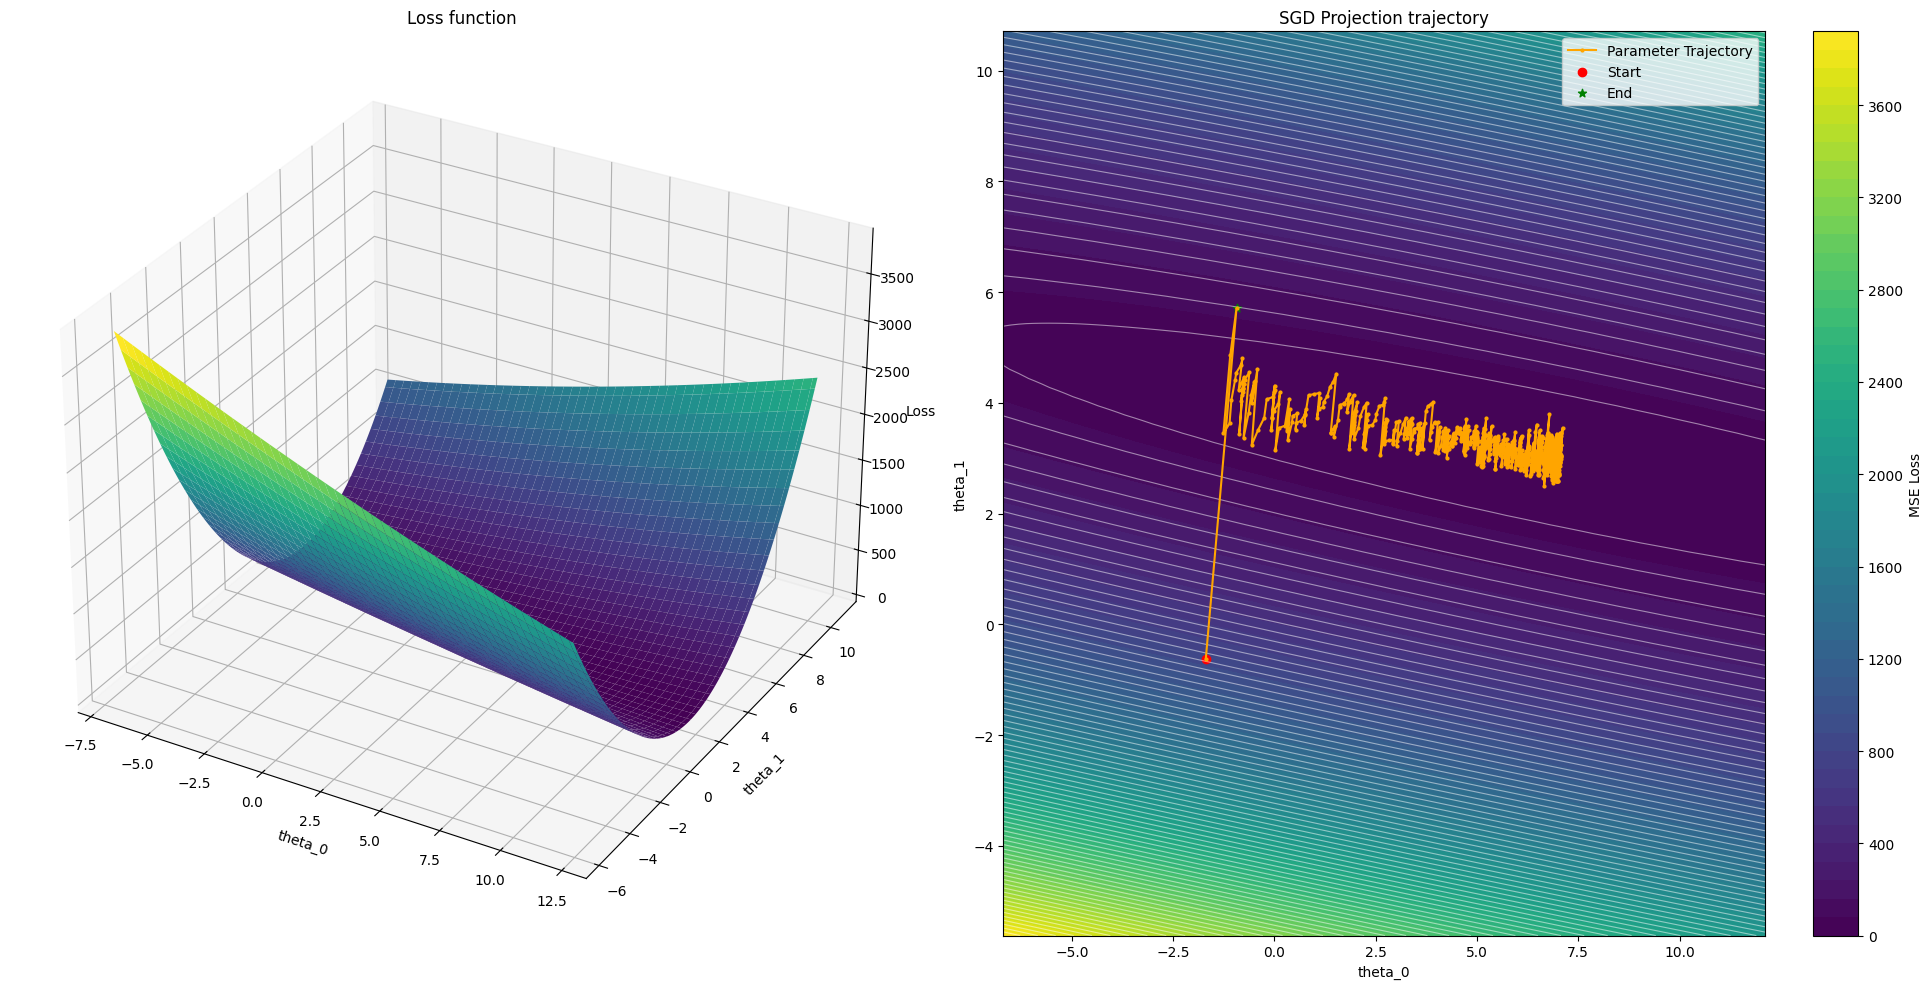

In [ ]:
pairs = np.array(gd.pairs)

theta0_vals = np.linspace(pairs[:,0].min() - 5, pairs[:,0].max() + 5, 100)
theta1_vals = np.linspace(pairs[:,1].min() - 2, pairs[:,1].max() + 2, 100)

T0, T1 = np.meshgrid(theta0_vals, theta1_vals)
Theta = np.c_[T0.ravel(),T1.ravel()]
Y_pred = np.c_[np.ones((X.shape[0],1)),X] @ Theta.T

print(Y_pred.shape, y.shape)

Loss = np.mean((Y_pred - y)**2, axis=0).reshape(T0.shape)


fig = plt.figure(figsize=(20,10))

ax1 = fig.add_subplot(121,projection='3d')
ax1.plot_surface(T0, T1, Loss, cmap='viridis')

ax1.set_xlabel('theta_0')
ax1.set_ylabel('theta_1')
ax1.set_zlabel('Loss')
ax1.set_title('Loss function')

ax2 = fig.add_subplot(122)

contour_filled = ax2.contourf(T0, T1, Loss, levels=50, cmap='viridis')
ax2.contour(T0, T1, Loss, levels=90, colors='white', linewidths = 0.8, alpha=0.5)
plt.colorbar(contour_filled,ax=ax2, label='MSE Loss')

ax2.plot(pairs[:,0],pairs[:,1], color='orange', marker = 'o', linewidth=1.5, label='Parameter Trajectory', markersize=2)
ax2.scatter(*pairs[0], label='Start', color='red')
ax2.scatter(*pairs[1], label='End', color='green', marker='*')

ax2.set_xlabel('theta_0')
ax2.set_ylabel('theta_1')
ax2.set_title('SGD Projection trajectory')

plt.legend(loc=0)
plt.tight_layout()
plt.show()